In [ ]:
#202431097_Alesandra Firstya Putri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.colors as mcolors

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


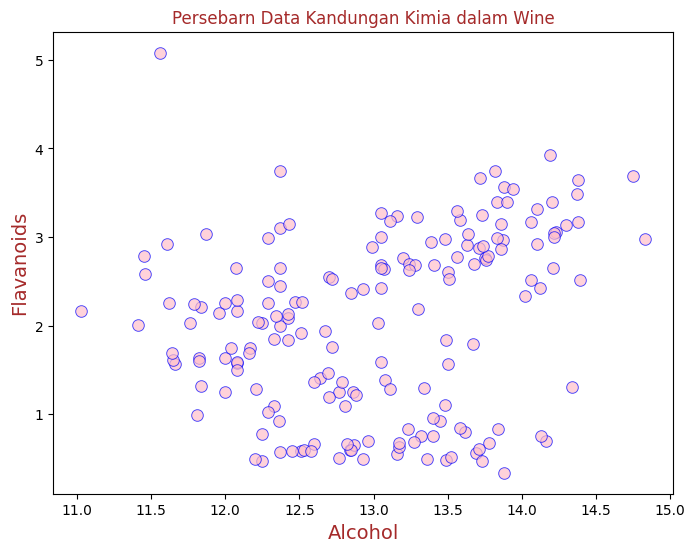

In [ ]:
#202431097_Alesandra Firstya Putri
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn import datasets

wine_data = datasets.load_wine()
df_wine = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
df_wine['target'] = wine_data.target

display(df_wine.head())
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_wine, x='alcohol', y='flavanoids', color='pink', s=70, edgecolor='blue', alpha=0.7)
plt.title('Persebaran Data Kandungan Kimia dalam Wine', color='brown')
plt.xlabel('Alcohol', fontsize=14, color='brown')
plt.ylabel('Flavanoids', fontsize=14, color='brown')
plt.show()

In [ ]:
#202431097_Alesandra Firstya Putri
X_knn = df_wine[['alcohol', 'flavanoids']].values
Y_knn = df_wine['target'].values

X_train_knn, X_test_knn, Y_train_knn, Y_test_knn = train_test_split(X_knn, Y_knn, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_knn)
X_test_scaled = scaler.transform(X_test_knn)

print("Standarisasi Selesai")

Standarisasi Selesai


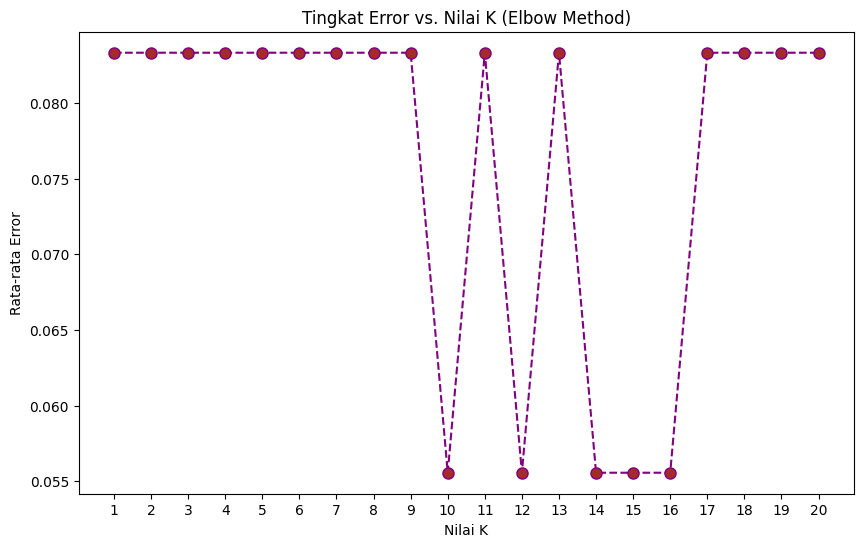

In [ ]:
#202431097_Alesandra Firstya Putri
tingkat_error = []
k_range = range(1, 21)

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, Y_train_knn)
    pred_i = knn.predict(X_test_scaled)
    tingkat_error.append(np.mean(pred_i != Y_test_knn))

plt.figure(figsize=(10, 6))
plt.plot(k_range, tingkat_error, color='purple', linestyle='dashed', marker='o', markerfacecolor='brown', markersize=8)
plt.title('Tingkat Error vs. Nilai K (Elbow Method)')
plt.xlabel('Nilai K')
plt.ylabel('Rata-rata Error')
plt.xticks(k_range)
plt.show()



Model KNN dilatih dengan K=10
Akurasi: 94.44%


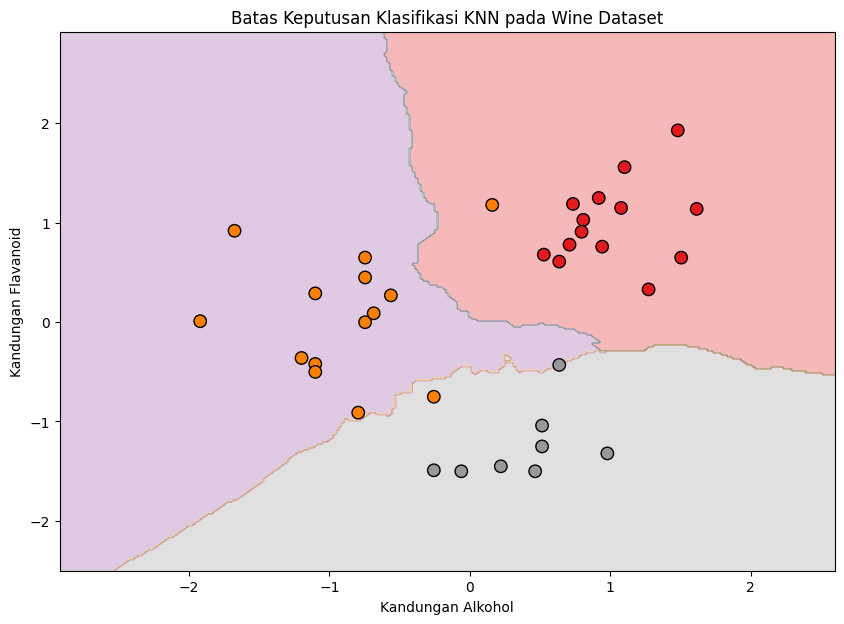

In [ ]:
#202431097_Alesandra Firstya Putri
k_optimal = 10
model_knn = KNeighborsClassifier(n_neighbors=k_optimal)
model_knn.fit(X_train_scaled, Y_train_knn)

Y_pred_knn = model_knn.predict(X_test_scaled)
akurasi = accuracy_score(Y_test_knn, Y_pred_knn)

print(f"Model KNN dilatih dengan K={k_optimal}")
print(f"Akurasi: {akurasi * 100:.2f}%")

plt.figure(figsize=(10, 7))

x_min, x_max = X_test_scaled[:, 0].min() - 1, X_test_scaled[:, 0].max() + 1
y_min, y_max = X_test_scaled[:, 1].min() - 1, X_test_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = model_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=Y_test_knn, cmap='Set1', edgecolor='k', s=80)

plt.title('Batas Keputusan Klasifikasi KNN pada Wine Dataset')
plt.xlabel('Kandungan Alkohol')
plt.ylabel('Kandungan Flavanoid')
plt.show()